# Experiment — Pulling Gene Weights out of a Target PC

**Loads the PCA loadings saved by `clean_transcriptomics.ipynb` and inspects the gene weights for a chosen principal component.**

Each PC is a linear combination of the batch-corrected genes. `clean_transcriptomics` persists those per-gene coefficients to `transcriptomics_pca_loadings.csv`, so this notebook just reads them — no need to rerun batch correction or refit PCA.

Inputs (produced by `clean_transcriptomics.ipynb`):
- `transcriptomics_pca_loadings.csv` — `gene_col`, `pca_mean`, then one column per PC (the weights)
- `transcriptomics_pca_meta.csv` — per-PC explained variance

In [1]:
CLEAN_DATA_PATH = '../cleaned_data'
TARGET_PC = 61  # 115 and 61 most significant
TOP_N = 10  # number of top-weighted genes to show

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load saved loadings

In [3]:
df_loadings = pd.read_csv(CLEAN_DATA_PATH + '/transcriptomics_pca_loadings.csv', index_col='gene_col')
df_meta = pd.read_csv(CLEAN_DATA_PATH + '/transcriptomics_pca_meta.csv')

pc_cols = [c for c in df_loadings.columns if c != 'pca_mean']
print(f'Loadings: {df_loadings.shape[0]} genes x {len(pc_cols)} PCs')
df_meta.head()

Loadings: 30822 genes x 290 PCs


,pc,explained_variance,explained_variance_ratio
0,TRAN_PC1,653.083541,0.332199
1,TRAN_PC2,147.107959,0.074828
2,TRAN_PC3,105.255989,0.053540
3,TRAN_PC4,78.067233,0.039710
4,TRAN_PC5,46.694869,0.023752


## Pull the weights out of the target PC

The column `TRAN_PC{N}` is the loading vector for that PC — one weight per gene. These are the coefficients that map centered gene expression onto the PC score.

In [4]:
pc_name = f'TRAN_PC{TARGET_PC}'
weights_series = df_loadings[pc_name]
var_ratio = df_meta.loc[df_meta['pc'] == pc_name, 'explained_variance_ratio'].iloc[0]

print(f'Target PC: {pc_name}')
print(f'Explained variance ratio: {var_ratio:.3%}')
print(f'Number of gene weights:    {len(weights_series)}')
print(f'Loading vector L2 norm:    {np.linalg.norm(weights_series.values):.4f} (PCA loadings are unit-norm)')
print(f'Weight range:              [{weights_series.min():.4f}, {weights_series.max():.4f}]')

Target PC: TRAN_PC61
Explained variance ratio: 0.148%
Number of gene weights:    30822
Loading vector L2 norm:    1.0000 (PCA loadings are unit-norm)
Weight range:              [-0.0925, 0.1365]


### Top genes driving the PC (by absolute weight)

In [5]:
top_genes = weights_series.reindex(weights_series.abs().sort_values(ascending=False).index).head(TOP_N)
top_table = top_genes.rename('weight').to_frame()
top_table['abs_weight'] = top_table['weight'].abs()
top_table['direction'] = np.where(top_table['weight'] >= 0, '+', '-')
top_table

,weight,abs_weight,direction
gene_col,,,
TRAN_ENSG00000204525_d0,0.136452,0.136452,+
TRAN_ENSG00000036448_d0,0.101389,0.101389,+
TRAN_ENSG00000168903_d0,-0.092467,0.092467,-
TRAN_ENSG00000274226_d0,0.089757,0.089757,+
TRAN_ENSG00000274611_d0,-0.087234,0.087234,-
TRAN_ENSG00000076864_d0,-0.072344,0.072344,-
TRAN_ENSG00000134184_d0,-0.065620,0.065620,-
TRAN_ENSG00000231412_d0,0.063939,0.063939,+
TRAN_ENSG00000214940_d0,0.056160,0.056160,+


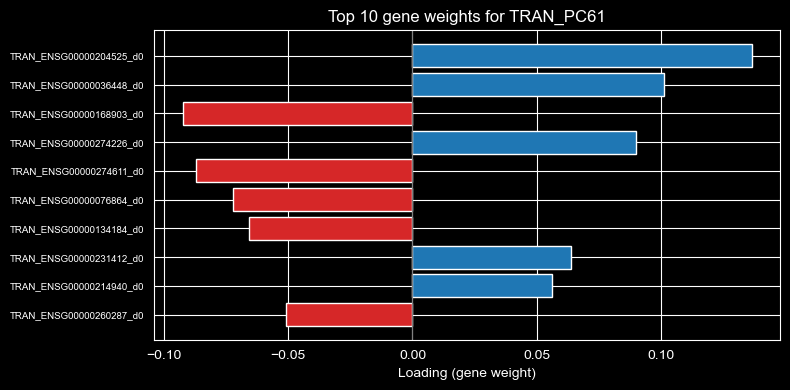

In [6]:
fig, ax = plt.subplots(figsize=(8, max(4, TOP_N * 0.25)))
plot_genes = top_genes[::-1]  # largest at top
colors = ['tab:red' if w < 0 else 'tab:blue' for w in plot_genes.values]
ax.barh(range(len(plot_genes)), plot_genes.values, color=colors)
ax.set_yticks(range(len(plot_genes)))
ax.set_yticklabels(plot_genes.index, fontsize=7)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Loading (gene weight)')
ax.set_title(f'Top {TOP_N} gene weights for {pc_name}')
plt.tight_layout()
plt.show()

### Export the target PC's weights

In [7]:
out_path = f'{CLEAN_DATA_PATH}/{pc_name}_weights.csv'
weights_series.rename('weight').rename_axis('gene_col').reset_index().to_csv(out_path, index=False)
print(f'Saved weights: {out_path}')

Saved weights: ../cleaned_data/TRAN_PC61_weights.csv
